# Data Curation

In [1]:
"""
Data Preprocessing Module
Handles loading, normalization, and dataset creation for time series forecasting
"""

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader


class TimeSeriesDataset:
    """Manages time series data loading and preprocessing"""

    def __init__(self, csv_path, target_columns=None, exclude_columns=None):
        """
        Initialize dataset from CSV file

        Args:
            csv_path: Path to CSV file
            target_columns: List of column names to use (None = all numeric columns)
            exclude_columns: List of column names to exclude (applied after target_columns)
        """
        self.csv_path = csv_path
        self.data = pd.read_csv(csv_path)

        # Select target columns
        if target_columns is not None:
            self.data = self.data[target_columns]
        else:
            # Use all columns except the first (assumed to be timestamp/index)
            self.data = self.data[self.data.columns[1:]]

        # Exclude specific columns if specified
        if exclude_columns is not None:
            self.data = self.data.drop(columns=exclude_columns, errors='ignore')

        self.num_variables = self.data.shape[1]
        self.total_timesteps = self.data.shape[0]

        print(f"Loaded dataset: {self.total_timesteps} timesteps, {self.num_variables} variables")

    def get_data(self):
        """Return the processed dataframe"""
        return self.data

    def get_numpy(self):
        """Return data as numpy array"""
        return self.data.to_numpy().astype(np.float32)


def create_dataloaders(data, seq_len, forecast_len, batch_size=64,
                       train_ratio=0.7, valid_ratio=0.1, step=1):
    """
    Create train, validation, and test dataloaders

    Args:
        data: numpy array of shape (T_total, M)
        seq_len: Length of input sequence (lookback window)
        forecast_len: Length of forecast horizon
        batch_size: Batch size for training
        train_ratio: Proportion of data for training
        valid_ratio: Proportion of data for validation
        step: Step size for sliding window

    Returns:
        train_loader, valid_loader, test_loader
    """
    T_total = data.shape[0]
    train_end = int(train_ratio * T_total)
    valid_end = int((train_ratio + valid_ratio) * T_total)

    print(f"\nData Split:")
    print(f"  Total timesteps: {T_total}")
    print(f"  Train: 0 to {train_end} ({train_ratio*100:.0f}%)")
    print(f"  Valid: {train_end} to {valid_end} ({valid_ratio*100:.0f}%)")
    print(f"  Test: {valid_end} to {T_total} ({(1-train_ratio-valid_ratio)*100:.0f}%)")

    train_data = normalize_data(data[:train_end])
    valid_data = normalize_data(data[train_end:valid_end])
    test_data = normalize_data(data[valid_end:])

    def sliding_window(d):
        """Create sliding windows from time series data"""
        X, y = [], []
        total = seq_len + forecast_len
        for i in range(0, len(d) - total + 1, step):
            X.append(d[i:i + seq_len])
            y.append(d[i + seq_len:i + total])
        return (torch.from_numpy(np.array(X)).float(),
                torch.from_numpy(np.array(y)).float())

    X_train, y_train = sliding_window(train_data)
    X_valid, y_valid = sliding_window(valid_data)
    X_test, y_test = sliding_window(test_data)

    print(f"\nDataloader Shapes:")
    print(f"  Train: X={X_train.shape}, y={y_train.shape}")
    print(f"  Valid: X={X_valid.shape}, y={y_valid.shape}")
    print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )
    valid_loader = DataLoader(
        TensorDataset(X_valid, y_valid),
        batch_size=batch_size,
        shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, valid_loader, test_loader


def normalize_data(data):
    """
    Z-score normalization across time dimension

    Args:
        data: pandas DataFrame or numpy array

    Returns:
        normalized_data, mean, std
    """
    if isinstance(data, pd.DataFrame):
        data = data.to_numpy().astype(np.float32)

    mean = data.mean(axis=0, keepdims=True)
    std = data.std(axis=0, keepdims=True)
    data_norm = (data - mean) / (std + 1e-8)

    return data_norm


def denormalize_data(data_norm, mean, std):
    """
    Reverse z-score normalization

    Args:
        data_norm: Normalized data
        mean: Original mean
        std: Original std

    Returns:
        denormalized data
    """
    if isinstance(data_norm, pd.DataFrame):
        data_norm = data_norm.to_numpy().astype(np.float32)

    return data_norm * (std + 1e-8) + mean

# Model Specifications

In [2]:
"""
PatchTST Model Architecture
Implements the PatchTST time series forecasting model with RevIN normalization
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
import math


class RevIN(nn.Module):
    """
    Reversible Instance Normalization.
    Normalizes each univariate series over time, stores mean/std,
    and can denormalize predictions back to the original scale.
    """
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(1))
        self.affine_bias = nn.Parameter(torch.zeros(1))

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B*M, L) — normalizes over time dim, stores stats"""
        self.mean = x.mean(dim=-1, keepdim=True)
        self.std = x.std(dim=-1, keepdim=True) + self.eps
        x = (x - self.mean) / self.std
        x = x * self.affine_weight + self.affine_bias
        return x

    def denormalize(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B*M, T) — model output in normalized space
        returns: (B*M, T) — back in original scale
        """
        x = (x - self.affine_bias) / (self.affine_weight + self.eps)
        x = x * self.std + self.mean
        return x


class PatchEmbedding(nn.Module):
    """Converts time series patches into embeddings with positional encoding"""
    def __init__(self, patch_size: int, d_model: int, num_patches: int):
        super().__init__()
        self.patch_size = patch_size
        self.d_model = d_model
        self.num_patches = num_patches
        self.Wp = nn.Linear(patch_size, d_model, bias=False)
        self.Wpos = nn.Parameter(torch.randn(d_model, num_patches))

    def forward(self, x_p: torch.Tensor) -> torch.Tensor:
        """x_p: (B*M, N, P) -> (B*M, D, N)"""
        x_d = self.Wp(x_p)
        x_d = x_d.transpose(-1, -2)
        x_d = x_d + self.Wpos
        return x_d


class BatchNormTransformerLayer(nn.Module):
    """
    Transformer encoder layer using BatchNorm1d instead of LayerNorm.
    Applies BatchNorm over the D dimension treating N as the sequence length.
    """
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int, dropout: float):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff1 = nn.Linear(d_model, dim_feedforward)
        self.ff2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm1d(d_model)
        self.bn2 = nn.BatchNorm1d(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B*M, N, D) -> (B*M, N, D)"""
        # Multi-head self-attention + residual + BN
        attn_out, _ = self.self_attn(x, x, x)
        x = x + self.dropout(attn_out)
        x = x.transpose(1, 2)
        x = self.bn1(x)
        x = x.transpose(1, 2)

        # Feed-forward network + residual + BN
        ff_out = self.ff2(self.dropout(F.gelu(self.ff1(x))))
        x = x + self.dropout(ff_out)
        x = x.transpose(1, 2)
        x = self.bn2(x)
        x = x.transpose(1, 2)

        return x


class PatchTST(nn.Module):
    """
    PatchTST: A Time Series Transformer with Patching and Channel Independence
    """
    def __init__(self, seq_len, forecast_len, patch_size, stride,
                 d_model, nhead=8, num_layers=3, dim_feedforward=256,
                 dropout=0.1, use_checkpoint=True):
        super().__init__()
        self.seq_len = seq_len
        self.patch_size = patch_size
        self.stride = stride
        self.forecast_len = forecast_len
        self.num_patches = math.floor((seq_len - patch_size) / stride) + 2
        self.use_checkpoint = use_checkpoint

        self.revin = RevIN()
        self.patch_embed = PatchEmbedding(patch_size, d_model, self.num_patches)

        self.encoder_layers = nn.ModuleList([
            BatchNormTransformerLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

        self.flatten = nn.Flatten(start_dim=-2)
        self.linear_head = nn.Linear(d_model * self.num_patches, forecast_len)

    def _patch(self, x):
        """Create patches from time series with padding"""
        S, P = self.stride, self.patch_size
        last_val = x[:, -1:]
        x_padded = torch.cat([x, last_val.expand(-1, S)], dim=-1)
        return x_padded.unfold(dimension=1, size=P, step=S)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch, L, M) - input sequences
        returns: (batch, M, T) - forecasts in original scale
        """
        B, L, M = x.shape

        # Reshape to process each series independently
        x = x.permute(0, 2, 1).reshape(B * M, L)

        # Normalize and store statistics
        x = self.revin.normalize(x)

        # Create patches
        x_p = self._patch(x)

        # Patch embedding
        x_d = self.patch_embed(x_p)
        x_d = x_d.transpose(-1, -2)

        # Transformer encoder
        for layer in self.encoder_layers:
            if self.use_checkpoint:
                x_d = checkpoint(layer, x_d, use_reentrant=False)
            else:
                x_d = layer(x_d)

        # Flatten and forecast
        out = self.flatten(x_d)
        out = self.linear_head(out)

        # Denormalize to original scale
        out = self.revin.denormalize(out)

        # Reshape to (batch, M, T)
        return out.reshape(B, M, self.forecast_len)

# Training

In [3]:
"""
Training and Evaluation Module
Handles model training, validation, and testing
"""

import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm


class Trainer:
    """Handles model training and evaluation"""

    def __init__(self, model, device='cpu'):
        """
        Initialize trainer

        Args:
            model: PatchTST model instance
            device: Device to train on ('cpu' or 'cuda')
        """
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.MSELoss()
        self.history = {
            'train_loss': [],
            'valid_loss': [],
            'test_loss': None
        }

    def train_epoch(self, train_loader, optimizer, accumulation_steps=1):
        """Train for one epoch"""
        self.model.train()
        epoch_loss = 0.0
        optimizer.zero_grad()

        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc="Training")
        for i, (x_batch, y_batch) in pbar:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.permute(0, 2, 1).to(self.device)

            out = self.model(x_batch)
            loss = self.criterion(out, y_batch) / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

            epoch_loss += loss.item() * accumulation_steps
            pbar.set_postfix({'loss': f'{loss.item() * accumulation_steps:.4f}'})

        # Handle remaining batches
        if (i + 1) % accumulation_steps != 0:
            optimizer.step()
            optimizer.zero_grad()

        return epoch_loss / len(train_loader)

    def validate(self, valid_loader):
        """Validate the model"""
        self.model.eval()
        valid_loss = 0.0

        with torch.no_grad():
            for x_batch, y_batch in valid_loader:
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.permute(0, 2, 1).to(self.device)
                out = self.model(x_batch)
                valid_loss += self.criterion(out, y_batch).item()

        return valid_loss / len(valid_loader)

    def train(self, train_loader, valid_loader, epochs=10, lr=1e-4,
              accumulation_steps=1, patience=5):
        """
        Train the model

        Args:
            train_loader: Training data loader
            valid_loader: Validation data loader
            epochs: Number of training epochs
            lr: Learning rate
            accumulation_steps: Gradient accumulation steps (simulates larger batch size)
            patience: Early stopping patience

        Returns:
            Training history dictionary
        """
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        best_valid_loss = float('inf')
        patience_counter = 0

        print(f"\nTraining Configuration:")
        print(f"  Epochs: {epochs}")
        print(f"  Learning rate: {lr}")
        print(f"  Accumulation steps: {accumulation_steps}")
        print(f"  Device: {self.device}")
        print(f"  Early stopping patience: {patience}")

        for epoch in range(epochs):
            print(f"\n{'='*60}")
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"{'='*60}")

            # Training
            train_loss = self.train_epoch(train_loader, optimizer, accumulation_steps)

            # Validation
            valid_loss = self.validate(valid_loader)

            # Learning rate scheduling
            scheduler.step()

            # Record history
            self.history['train_loss'].append(train_loss)
            self.history['valid_loss'].append(valid_loss)

            print(f"\nEpoch {epoch+1} Summary:")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Valid Loss: {valid_loss:.4f}")
            print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6f}")

            # Early stopping
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), '/best_model.pt')
                print(f"  ✓ New best model saved (Valid Loss: {best_valid_loss:.4f})")
            else:
                patience_counter += 1
                print(f"  No improvement ({patience_counter}/{patience})")

                if patience_counter >= patience:
                    print(f"\nEarly stopping triggered after {epoch+1} epochs")
                    break

        # Load best model
        self.model.load_state_dict(torch.load('/best_model.pt'))
        print(f"\n{'='*60}")
        print(f"Training completed. Best validation loss: {best_valid_loss:.4f}")
        print(f"{'='*60}")

        return self.history

    def evaluate(self, test_loader, return_predictions=False):
        """
        Evaluate model on test set

        Args:
            test_loader: Test data loader
            return_predictions: Whether to return predictions and targets

        Returns:
            test_loss (and optionally predictions, targets)
        """
        self.model.eval()
        test_loss = 0.0
        all_predictions = []
        all_targets = []

        print("\nEvaluating on test set...")
        with torch.no_grad():
            for x_batch, y_batch in tqdm(test_loader):
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.permute(0, 2, 1).to(self.device)
                out = self.model(x_batch)
                test_loss += self.criterion(out, y_batch).item()

                if return_predictions:
                    all_predictions.append(out.cpu().numpy())
                    all_targets.append(y_batch.cpu().numpy())

        test_loss = test_loss / len(test_loader)
        self.history['test_loss'] = test_loss

        print(f"\n{'='*60}")
        print(f"Test Loss (MSE): {test_loss:.4f}")
        print(f"Test RMSE: {np.sqrt(test_loss):.4f}")
        print(f"{'='*60}")

        if return_predictions:
            predictions = np.concatenate(all_predictions, axis=0)
            targets = np.concatenate(all_targets, axis=0)
            return test_loss, predictions, targets

        return test_loss

    def get_history(self):
        """Return training history"""
        return self.history

# Visualization

In [4]:
"""
Visualization Module
Provides functions to visualize training results and predictions
"""

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")


def plot_training_history(history, save_path=None):
    """
    Plot training and validation loss curves

    Args:
        history: Dictionary with 'train_loss' and 'valid_loss' lists
        save_path: Optional path to save the figure
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    epochs = range(1, len(history['train_loss']) + 1)

    ax.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
    ax.plot(epochs, history['valid_loss'], 'r-s', label='Validation Loss', linewidth=2)

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss (MSE)', fontsize=12)
    ax.set_title('Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Add text box with final losses
    textstr = f'Final Train Loss: {history["train_loss"][-1]:.4f}\n'
    textstr += f'Final Valid Loss: {history["valid_loss"][-1]:.4f}'
    if history.get('test_loss') is not None:
        textstr += f'\nTest Loss: {history["test_loss"]:.4f}'

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


def plot_predictions(predictions, targets, num_samples=3, num_variables=5, save_path=None):
    """
    Plot sample predictions vs actual values

    Args:
        predictions: Numpy array of shape (num_samples, num_variables, forecast_len)
        targets: Numpy array of shape (num_samples, num_variables, forecast_len)
        num_samples: Number of samples to plot
        num_variables: Number of variables to plot per sample
        save_path: Optional path to save the figure
    """
    num_samples = min(num_samples, predictions.shape[0])
    num_variables = min(num_variables, predictions.shape[1])

    fig, axes = plt.subplots(num_samples, num_variables,
                            figsize=(4*num_variables, 3*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)
    if num_variables == 1:
        axes = axes.reshape(-1, 1)

    for i in range(num_samples):
        for j in range(num_variables):
            ax = axes[i, j]

            pred = predictions[i, j, :]
            target = targets[i, j, :]
            timesteps = range(len(pred))

            ax.plot(timesteps, target, 'b-o', label='Actual', linewidth=2, markersize=4)
            ax.plot(timesteps, pred, 'r--s', label='Predicted', linewidth=2, markersize=4)

            ax.set_xlabel('Forecast Timestep', fontsize=10)
            ax.set_ylabel('Value', fontsize=10)
            ax.set_title(f'Sample {i+1}, Variable {j+1}', fontsize=11, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

            # Calculate MSE for this series
            mse = np.mean((pred - target) ** 2)
            ax.text(0.05, 0.95, f'MSE: {mse:.4f}', transform=ax.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


def plot_error_distribution(predictions, targets, save_path=None):
    """
    Plot distribution of prediction errors

    Args:
        predictions: Numpy array of predictions
        targets: Numpy array of targets
        save_path: Optional path to save the figure
    """
    errors = (predictions - targets).flatten()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    axes[0].set_xlabel('Prediction Error', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Q-Q plot
    from scipy import stats
    stats.probplot(errors, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot (Normal Distribution)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Add statistics
    textstr = f'Mean Error: {np.mean(errors):.4f}\n'
    textstr += f'Std Error: {np.std(errors):.4f}\n'
    textstr += f'MAE: {np.mean(np.abs(errors)):.4f}\n'
    textstr += f'RMSE: {np.sqrt(np.mean(errors**2)):.4f}'

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


def plot_variable_performance(predictions, targets, variable_names=None, save_path=None):
    """
    Plot MSE for each variable

    Args:
        predictions: Numpy array of shape (num_samples, num_variables, forecast_len)
        targets: Numpy array of shape (num_samples, num_variables, forecast_len)
        variable_names: List of variable names (optional)
        save_path: Optional path to save the figure
    """
    num_variables = predictions.shape[1]

    mse_per_variable = []
    for i in range(num_variables):
        mse = np.mean((predictions[:, i, :] - targets[:, i, :]) ** 2)
        mse_per_variable.append(mse)

    if variable_names is None:
        variable_names = [f'Var {i+1}' for i in range(num_variables)]

    # If too many variables, show top 20 worst performing
    if num_variables > 20:
        top_indices = np.argsort(mse_per_variable)[-20:]
        mse_per_variable = [mse_per_variable[i] for i in top_indices]
        variable_names = [variable_names[i] for i in top_indices]

    fig, ax = plt.subplots(figsize=(12, max(6, len(mse_per_variable) * 0.3)))

    colors = plt.cm.viridis(np.linspace(0, 1, len(mse_per_variable)))
    bars = ax.barh(range(len(mse_per_variable)), mse_per_variable, color=colors)

    ax.set_yticks(range(len(mse_per_variable)))
    ax.set_yticklabels(variable_names, fontsize=9)
    ax.set_xlabel('MSE', fontsize=12)
    ax.set_title('MSE per Variable (Lower is Better)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, mse_per_variable)):
        ax.text(value, i, f' {value:.4f}', va='center', fontsize=8)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


def plot_forecast_comparison(predictions, targets, sample_idx=0,
                            variable_indices=None, save_path=None):
    """
    Plot detailed comparison for specific variables from one sample

    Args:
        predictions: Numpy array of predictions
        targets: Numpy array of targets
        sample_idx: Index of sample to visualize
        variable_indices: List of variable indices to plot (None = first 6)
        save_path: Optional path to save the figure
    """
    if variable_indices is None:
        variable_indices = list(range(min(6, predictions.shape[1])))

    num_vars = len(variable_indices)
    cols = 2
    rows = (num_vars + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows))
    axes = axes.flatten() if num_vars > 1 else [axes]

    for idx, var_idx in enumerate(variable_indices):
        ax = axes[idx]

        pred = predictions[sample_idx, var_idx, :]
        target = targets[sample_idx, var_idx, :]
        timesteps = range(len(pred))

        ax.plot(timesteps, target, 'b-o', label='Ground Truth',
               linewidth=2.5, markersize=6, alpha=0.7)
        ax.plot(timesteps, pred, 'r--s', label='Prediction',
               linewidth=2.5, markersize=6, alpha=0.7)

        # Shade the error
        ax.fill_between(timesteps, target, pred, alpha=0.2, color='gray')

        mse = np.mean((pred - target) ** 2)
        mae = np.mean(np.abs(pred - target))

        ax.set_xlabel('Forecast Timestep', fontsize=11)
        ax.set_ylabel('Value', fontsize=11)
        ax.set_title(f'Variable {var_idx} | MSE: {mse:.4f} | MAE: {mae:.4f}',
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(num_vars, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Forecast Comparison - Sample {sample_idx}',
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()

# Different Configurations

In [6]:
"""
Configuration Module
Centralized configuration for model hyperparameters and training settings
"""

import math


class PatchTSTConfig:
    """Configuration class for PatchTST model and training"""

    def __init__(self):
        # Data parameters
        self.seq_len = 336          # Input sequence length (L)
        self.forecast_len = 96      # Forecast horizon (T)
        self.train_ratio = 0.7      # Training data ratio
        self.valid_ratio = 0.1      # Validation data ratio

        # Patching parameters
        self.patch_size = 16        # Patch size (P)
        self.stride = 8            # Stride for patching (S)

        # Model architecture
        self.d_model = 128          # Model dimension (D)
        self.nhead = 16             # Number of attention heads (H)
        self.num_layers = 3         # Number of transformer layers
        self.dim_feedforward = 256  # Feedforward network dimension (f)
        self.dropout = 0.2          # Dropout rate (p)
        self.use_checkpoint = True  # Use gradient checkpointing

        # Training parameters
        self.batch_size = 4         # Batch size
        self.accumulation_steps = 16  # Gradient accumulation steps
        self.epochs = 10            # Number of training epochs
        self.learning_rate = 1e-4   # Learning rate
        self.patience = 5           # Early stopping patience

        # Data parameters
        self.step = 8              # Sliding window step size

        # Compute derived parameters
        self.num_patches = math.floor((self.seq_len - self.patch_size) / self.stride) + 2
        self.effective_batch_size = self.batch_size * self.accumulation_steps

    def update(self, **kwargs):
        """Update configuration with keyword arguments"""
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            else:
                raise ValueError(f"Unknown configuration parameter: {key}")

        # Recompute derived parameters
        self.num_patches = math.floor((self.seq_len - self.patch_size) / self.stride) + 2
        self.effective_batch_size = self.batch_size * self.accumulation_steps

    def print_config(self):
        """Print all configuration parameters"""
        print("\n" + "="*60)
        print("PatchTST Configuration")
        print("="*60)

        print("\nData Parameters:")
        print(f"  Sequence Length (L): {self.seq_len}")
        print(f"  Forecast Length (T): {self.forecast_len}")
        print(f"  Train/Valid/Test Split: {self.train_ratio:.1%}/{self.valid_ratio:.1%}/{1-self.train_ratio-self.valid_ratio:.1%}")
        print(f"  Sliding Window Step: {self.step}")

        print("\nPatching Parameters:")
        print(f"  Patch Size (P): {self.patch_size}")
        print(f"  Stride (S): {self.stride}")
        print(f"  Number of Patches (N): {self.num_patches}")

        print("\nModel Architecture:")
        print(f"  Model Dimension (D): {self.d_model}")
        print(f"  Attention Heads (H): {self.nhead}")
        print(f"  Transformer Layers: {self.num_layers}")
        print(f"  Feedforward Dimension: {self.dim_feedforward}")
        print(f"  Dropout: {self.dropout}")
        print(f"  Gradient Checkpointing: {self.use_checkpoint}")

        print("\nTraining Parameters:")
        print(f"  Batch Size: {self.batch_size}")
        print(f"  Accumulation Steps: {self.accumulation_steps}")
        print(f"  Effective Batch Size: {self.effective_batch_size}")
        print(f"  Epochs: {self.epochs}")
        print(f"  Learning Rate: {self.learning_rate}")
        print(f"  Early Stopping Patience: {self.patience}")
        print("="*60 + "\n")

    def to_dict(self):
        """Convert configuration to dictionary"""
        return {
            'seq_len': self.seq_len,
            'forecast_len': self.forecast_len,
            'patch_size': self.patch_size,
            'stride': self.stride,
            'd_model': self.d_model,
            'nhead': self.nhead,
            'num_layers': self.num_layers,
            'dim_feedforward': self.dim_feedforward,
            'dropout': self.dropout,
            'use_checkpoint': self.use_checkpoint,
            'batch_size': self.batch_size,
            'accumulation_steps': self.accumulation_steps,
            'epochs': self.epochs,
            'learning_rate': self.learning_rate,
            'train_ratio': self.train_ratio,
            'valid_ratio': self.valid_ratio,
            'step': self.step,
            'patience': self.patience
        }


# Preset configurations for different scenarios
CONFIGS = {
    'default': PatchTSTConfig(),

    'fast_test': PatchTSTConfig(),  # Quick testing

    'high_performance': PatchTSTConfig(),  # Better accuracy

    'low_memory': PatchTSTConfig(),  # Reduced memory usage
    'patchtst64': PatchTSTConfig()
}

# Configure fast_test
CONFIGS['fast_test'].update(
    epochs=5,
    batch_size=8,
    d_model=64,
    num_layers=2,
    nhead=8,
    dim_feedforward=128
)

# Configure high_performance
CONFIGS['high_performance'].update(
    epochs=20,
    d_model=256,
    num_layers=4,
    nhead=16,
    dim_feedforward=512,
    dropout=0.2,
    patience=10
)

# Configure low_memory
CONFIGS['low_memory'].update(
    batch_size=2,
    accumulation_steps=32,
    d_model=64,
    num_layers=2,
    nhead=8,
    dim_feedforward=128,
    use_checkpoint=True
)
CONFIGS['patchtst64'].update(
    seq_len=512,
    forecast_len=96
)


def get_config(name='default'):
    """
    Get a configuration by name

    Args:
        name: Configuration name ('default', 'fast_test', 'high_performance', 'low_memory')

    Returns:
        PatchTSTConfig instance
    """
    if name not in CONFIGS:
        raise ValueError(f"Unknown configuration: {name}. Available: {list(CONFIGS.keys())}")
    return CONFIGS[name]

# Main Function Call

In [ ]:
"""
Main Execution Script
Demonstrates how to use the modular PatchTST framework
"""

import torch
import numpy as np
import os
import argparse

# from model import PatchTST
# from data_utils import TimeSeriesDataset, create_dataloaders
# from trainer import Trainer
# from visualize import (plot_training_history, plot_predictions,
#                       plot_error_distribution, plot_variable_performance,
#                       plot_forecast_comparison)
# from config import get_config


def set_seed(seed=2021):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def main(csv_path, config_name='default', output_dir='/outputs',
         exclude_first_col=True, seed=2021):
    """
    Main training and evaluation pipeline

    Args:
        csv_path: Path to CSV file
        config_name: Name of configuration to use
        output_dir: Directory to save outputs
        exclude_first_col: Whether to exclude first column (usually timestamp)
        seed: Random seed
    """
    # Set random seed
    set_seed(seed)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Load configuration
    config = get_config(config_name)
    config.print_config()

    # Set device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"\nUsing device: {device}")
    if device == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")

    print("\n" + "="*60)
    print("STEP 1: Loading Data")
    print("="*60)

    # Load dataset
    dataset = TimeSeriesDataset(csv_path=csv_path)

    # Exclude first column if needed
    if exclude_first_col:
        first_col = dataset.data.columns[0]
        dataset.data = dataset.data.drop(columns=[first_col])
        dataset.num_variables = dataset.data.shape[1]
        print(f"Excluded column: {first_col}")

    # Get data as numpy array
    data = dataset.get_numpy()

    # Create dataloaders
    train_loader, valid_loader, test_loader = create_dataloaders(
        data=data,
        seq_len=config.seq_len,
        forecast_len=config.forecast_len,
        batch_size=config.batch_size,
        train_ratio=config.train_ratio,
        valid_ratio=config.valid_ratio,
        step=config.step
    )

    print("\n" + "="*60)
    print("STEP 2: Initializing Model")
    print("="*60)

    # Initialize model
    model = PatchTST(
        seq_len=config.seq_len,
        forecast_len=config.forecast_len,
        patch_size=config.patch_size,
        stride=config.stride,
        d_model=config.d_model,
        nhead=config.nhead,
        num_layers=config.num_layers,
        dim_feedforward=config.dim_feedforward,
        dropout=config.dropout,
        use_checkpoint=config.use_checkpoint
    )

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Parameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,}")

    print("\n" + "="*60)
    print("STEP 3: Training Model")
    print("="*60)

    # Initialize trainer
    trainer = Trainer(model=model, device=device)

    # Train model
    history = trainer.train(
        train_loader=train_loader,
        valid_loader=valid_loader,
        epochs=config.epochs,
        lr=config.learning_rate,
        accumulation_steps=config.accumulation_steps,
        patience=config.patience
    )

    print("\n" + "="*60)
    print("STEP 4: Evaluating Model")
    print("="*60)

    # Evaluate on test set
    test_loss, predictions, targets = trainer.evaluate(
        test_loader=test_loader,
        return_predictions=True
    )

    print("\n" + "="*60)
    print("STEP 5: Visualizing Results")
    print("="*60)

    # Plot training history
    print("\nGenerating training history plot...")
    plot_training_history(
        history=history,
        save_path=os.path.join(output_dir, 'training_history.png')
    )

    # Plot sample predictions
    print("\nGenerating sample predictions plot...")
    plot_predictions(
        predictions=predictions,
        targets=targets,
        num_samples=3,
        num_variables=5,
        save_path=os.path.join(output_dir, 'sample_predictions.png')
    )

    # Plot error distribution
    print("\nGenerating error distribution plot...")
    plot_error_distribution(
        predictions=predictions,
        targets=targets,
        save_path=os.path.join(output_dir, 'error_distribution.png')
    )

    # Plot variable performance
    print("\nGenerating variable performance plot...")
    plot_variable_performance(
        predictions=predictions,
        targets=targets,
        save_path=os.path.join(output_dir, 'variable_performance.png')
    )

    # Plot detailed forecast comparison
    print("\nGenerating detailed forecast comparison...")
    plot_forecast_comparison(
        predictions=predictions,
        targets=targets,
        sample_idx=0,
        save_path=os.path.join(output_dir, 'forecast_comparison.png')
    )

    print("\n" + "="*60)
    print("STEP 6: Saving Results")
    print("="*60)

    # Save model
    model_path = os.path.join(output_dir, 'final_model.pt')
    torch.save(model.state_dict(), model_path)
    print(f"\nModel saved to: {model_path}")

    # Save configuration
    import json
    config_path = os.path.join(output_dir, 'config.json')
    with open(config_path, 'w') as f:
        json.dump(config.to_dict(), f, indent=2)
    print(f"Configuration saved to: {config_path}")

    # Save results summary
    results = {
        'train_loss': float(history['train_loss'][-1]),
        'valid_loss': float(history['valid_loss'][-1]),
        'test_loss': float(test_loss),
        'test_rmse': float(np.sqrt(test_loss)),
        'num_parameters': int(total_params),
        'num_variables': int(data.shape[1]),
        'total_timesteps': int(data.shape[0])
    }

    results_path = os.path.join(output_dir, 'results.json')
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Results saved to: {results_path}")

    print("\n" + "="*60)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*60)
    print(f"\nAll outputs saved to: {output_dir}")
    print(f"\nFinal Results:")
    print(f"  Train Loss: {results['train_loss']:.4f}")
    print(f"  Valid Loss: {results['valid_loss']:.4f}")
    print(f"  Test Loss: {results['test_loss']:.4f}")
    print(f"  Test RMSE: {results['test_rmse']:.4f}")

    return model, history, predictions, targets


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Train PatchTST on time series data')
    parser.add_argument('--csv_path', type=str, required=True,
                       help='Path to CSV file')
    parser.add_argument('--config', type=str, default='default',
                       choices=['default', 'fast_test', 'high_performance', 'low_memory'],
                       help='Configuration preset to use')
    parser.add_argument('--output_dir', type=str, default='/outputs',
                       help='Directory to save outputs')
    parser.add_argument('--seed', type=int, default=2021,
                       help='Random seed for reproducibility')
    parser.add_argument('--keep_first_col', action='store_true',
                       help='Keep first column (by default it is excluded)')

    args = parser.parse_args()

    main(
        csv_path=args.csv_path,
        config_name=args.config,
        output_dir=args.output_dir,
        exclude_first_col=not args.keep_first_col,
        seed=args.seed
    )

# Custom Run

In [7]:
"""
Simple Example Script
Demonstrates minimal usage of the PatchTST framework
"""

# Set random seed
torch.manual_seed(2021)
np.random.seed(2021)

print("="*60)
print("PatchTST Simple Example")
print("="*60)

# 1. Load your data
print("\n1. Loading data...")
dataset = TimeSeriesDataset(csv_path="electricity.csv")
data = dataset.get_numpy()

# 2. Choose a configuration
print("\n2. Loading configuration...")
config = get_config('patchtst64')  # Use 'fast_test' for quick demo

# 3. Create data loaders
print("\n3. Creating data loaders...")
train_loader, valid_loader, test_loader = create_dataloaders(
    data=data,
    seq_len=config.seq_len,
    forecast_len=config.forecast_len,
    batch_size=config.batch_size,
    step=config.step
)

# 4. Initialize model
print("\n4. Initializing model...")
model = PatchTST(
    seq_len=config.seq_len,
    forecast_len=config.forecast_len,
    patch_size=config.patch_size,
    stride=config.stride,
    d_model=config.d_model,
    nhead=config.nhead,
    num_layers=config.num_layers,
    dim_feedforward=config.dim_feedforward,
    dropout=config.dropout
)

PatchTST Simple Example

1. Loading data...
Loaded dataset: 26304 timesteps, 321 variables

2. Loading configuration...

3. Creating data loaders...

Data Split:
  Total timesteps: 26304
  Train: 0 to 18412 (70%)
  Valid: 18412 to 21043 (10%)
  Test: 21043 to 26304 (20%)

Dataloader Shapes:
  Train: X=torch.Size([2226, 512, 321]), y=torch.Size([2226, 96, 321])
  Valid: X=torch.Size([253, 512, 321]), y=torch.Size([253, 96, 321])
  Test:  X=torch.Size([582, 512, 321]), y=torch.Size([582, 96, 321])

4. Initializing model...


In [8]:

# 5. Train model
print("\n5. Training model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
trainer = Trainer(model=model, device=device)

history = trainer.train(
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=config.epochs,
    lr=config.learning_rate,
    accumulation_steps=config.accumulation_steps
)



5. Training model...

Training Configuration:
  Epochs: 10
  Learning rate: 0.0001
  Accumulation steps: 16
  Device: cuda
  Early stopping patience: 5

Epoch 1/10


Training: 100%|██████████| 557/557 [03:11<00:00,  2.91it/s, loss=0.2228]



Epoch 1 Summary:
  Train Loss: 0.3604
  Valid Loss: 0.2635
  Learning Rate: 0.000098
  ✓ New best model saved (Valid Loss: 0.2635)

Epoch 2/10


Training: 100%|██████████| 557/557 [03:18<00:00,  2.80it/s, loss=0.3212]



Epoch 2 Summary:
  Train Loss: 0.2090
  Valid Loss: 0.2167
  Learning Rate: 0.000090
  ✓ New best model saved (Valid Loss: 0.2167)

Epoch 3/10


...


Epoch 8 Summary:
  Train Loss: 0.1631
  Valid Loss: 0.1806
  Learning Rate: 0.000010
  ✓ New best model saved (Valid Loss: 0.1806)

Epoch 9/10


Training: 100%|██████████| 557/557 [03:21<00:00,  2.77it/s, loss=0.1702]



Epoch 9 Summary:
  Train Loss: 0.1622
  Valid Loss: 0.1797
  Learning Rate: 0.000002
  ✓ New best model saved (Valid Loss: 0.1797)

Epoch 10/10


Training: 100%|██████████| 557/557 [03:21<00:00,  2.76it/s, loss=0.2370]



Epoch 10 Summary:
  Train Loss: 0.1618
  Valid Loss: 0.1796
  Learning Rate: 0.000000
  ✓ New best model saved (Valid Loss: 0.1796)

Training completed. Best validation loss: 0.1796


### patchtst42

In [15]:

# 5. Train model
print("\n5. Training model...step=8")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
trainer = Trainer(model=model, device=device)

history = trainer.train(
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=config.epochs,
    lr=config.learning_rate,
    accumulation_steps=config.accumulation_steps
)



5. Training model...step=8

Training Configuration:
  Epochs: 10
  Learning rate: 0.0001
  Accumulation steps: 16
  Device: cuda
  Early stopping patience: 5

Epoch 1/10


Training: 100%|██████████| 562/562 [02:24<00:00,  3.90it/s, loss=0.2389]



Epoch 1 Summary:
  Train Loss: 0.3698
  Valid Loss: 0.2705
  Learning Rate: 0.000098
  ✓ New best model saved (Valid Loss: 0.2705)

Epoch 2/10


Training: 100%|██████████| 562/562 [02:22<00:00,  3.95it/s, loss=0.1800]



Epoch 2 Summary:
  Train Loss: 0.2166
  Valid Loss: 0.2246
  Learning Rate: 0.000090
  ✓ New best model saved (Valid Loss: 0.2246)

Epoch 3/10


...


Epoch 8 Summary:
  Train Loss: 0.1687
  Valid Loss: 0.1867
  Learning Rate: 0.000010
  ✓ New best model saved (Valid Loss: 0.1867)

Epoch 9/10


Training: 100%|██████████| 562/562 [02:22<00:00,  3.95it/s, loss=0.1464]



Epoch 9 Summary:
  Train Loss: 0.1678
  Valid Loss: 0.1860
  Learning Rate: 0.000002
  ✓ New best model saved (Valid Loss: 0.1860)

Epoch 10/10


Training: 100%|██████████| 562/562 [02:22<00:00,  3.95it/s, loss=0.1431]



Epoch 10 Summary:
  Train Loss: 0.1674
  Valid Loss: 0.1858
  Learning Rate: 0.000000
  ✓ New best model saved (Valid Loss: 0.1858)

Training completed. Best validation loss: 0.1858


In [16]:

# 6. Evaluate
print("\n6. Evaluating model...step=8")
test_loss, predictions, targets = trainer.evaluate(
    test_loader=test_loader,
    return_predictions=True
)



6. Evaluating model...step=8

Evaluating on test set...


100%|██████████| 151/151 [00:08<00:00, 18.29it/s]



Test Loss (MSE): 0.1848
Test RMSE: 0.4299


In [11]:

# 6. Evaluate
print("\n6. Evaluating model...")
test_loss, predictions, targets = trainer.evaluate(
    test_loader=test_loader,
    return_predictions=True
)



6. Evaluating model...

Evaluating on test set...


100%|██████████| 101/101 [00:03<00:00, 26.74it/s]



Test Loss (MSE): 0.2264
Test RMSE: 0.4758


### Patchtst64

In [9]:

# 6. Evaluate
print("\n6. Evaluating model...patchtst64")
test_loss, predictions, targets = trainer.evaluate(
    test_loader=test_loader,
    return_predictions=True
)



6. Evaluating model...patchtst64

Evaluating on test set...


100%|██████████| 146/146 [00:10<00:00, 13.80it/s]


Test Loss (MSE): 0.1731
Test RMSE: 0.4160



Generating training history plot...


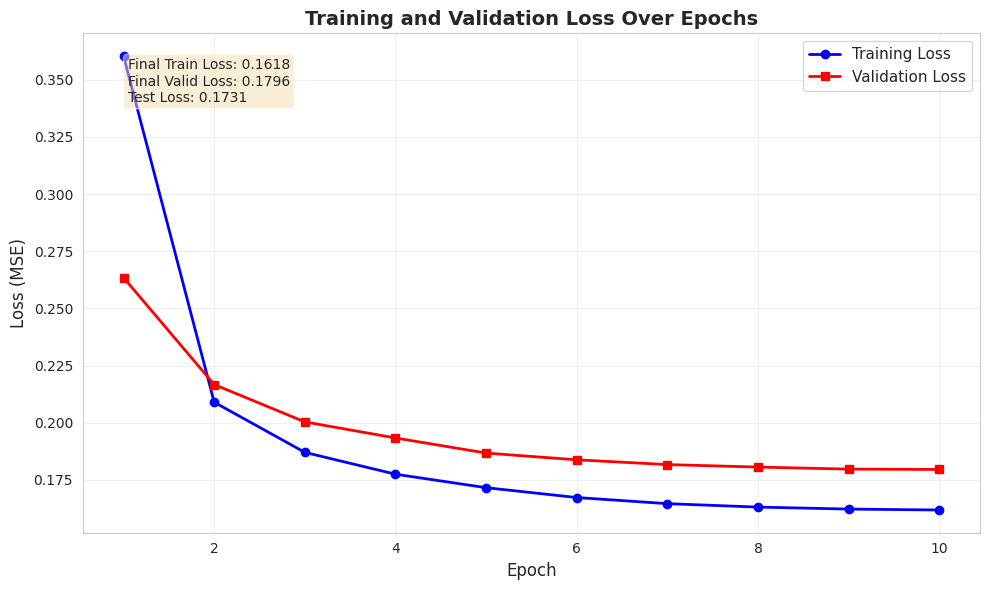


Generating sample predictions plot...


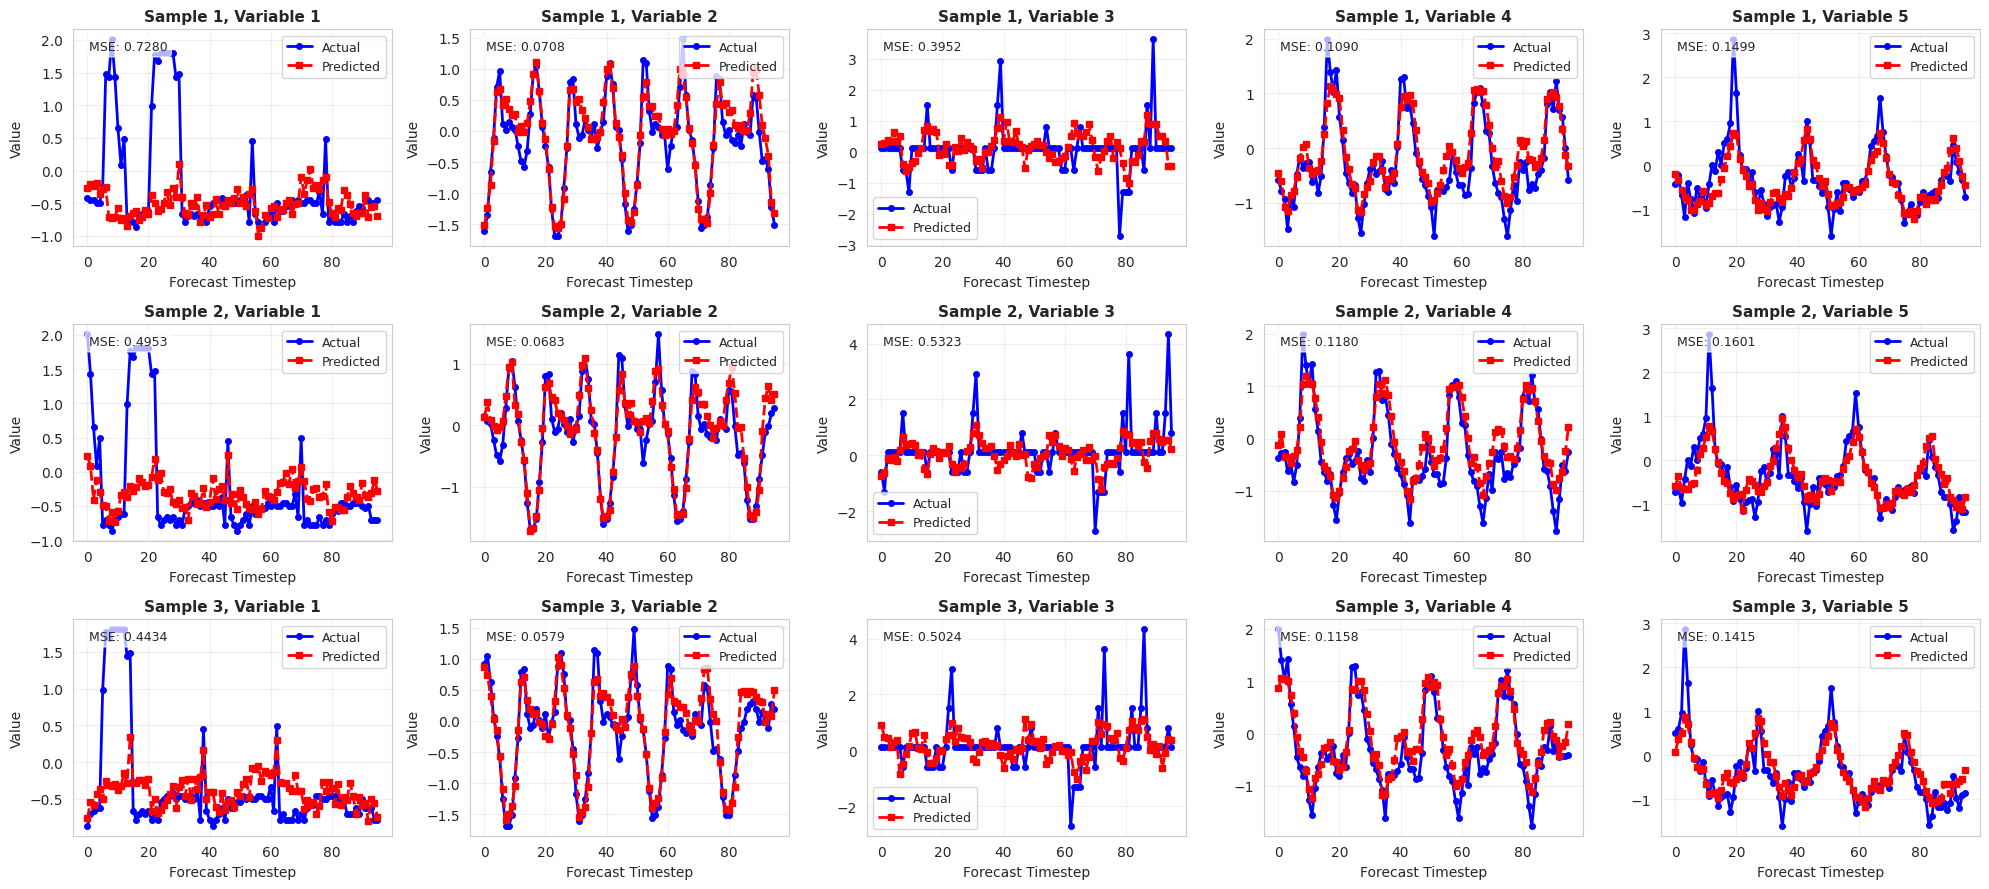


Generating error distribution plot...


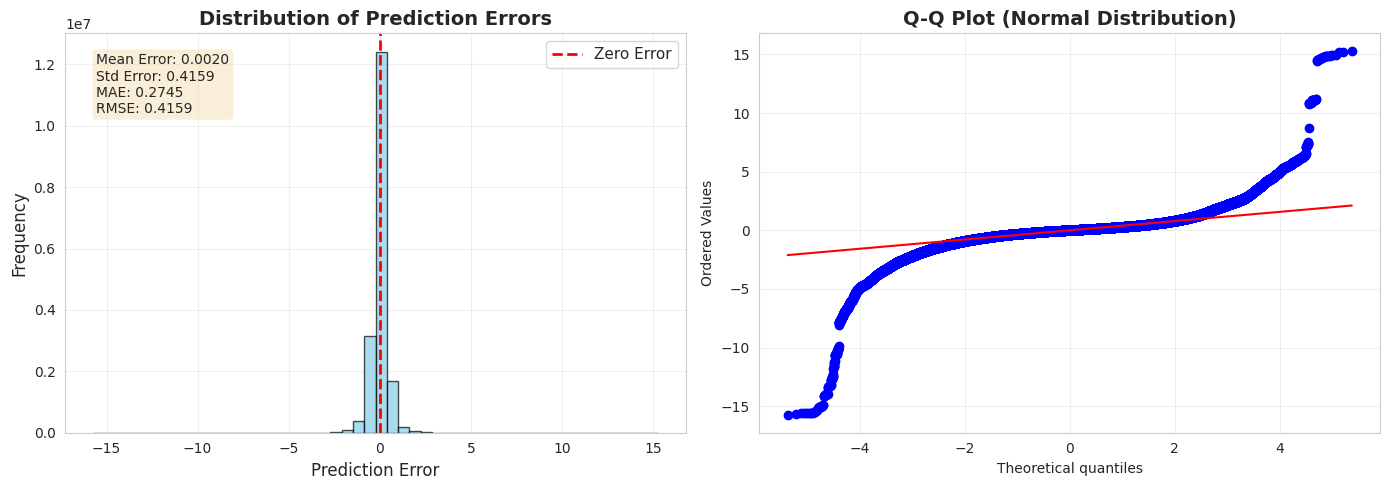


Generating variable performance plot...


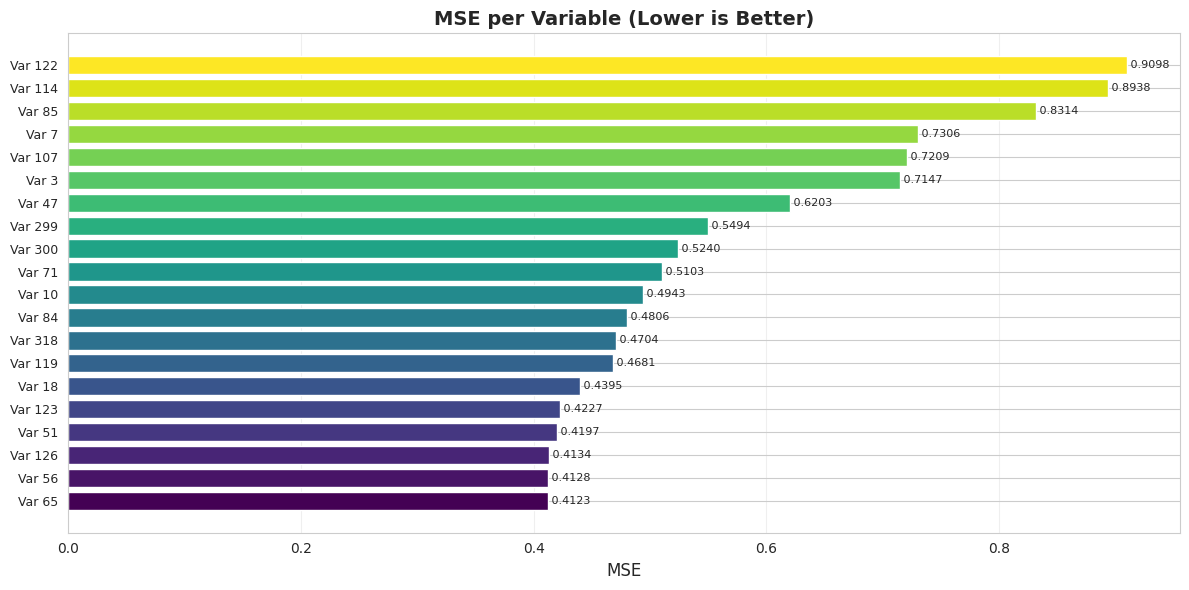


Generating detailed forecast comparison...


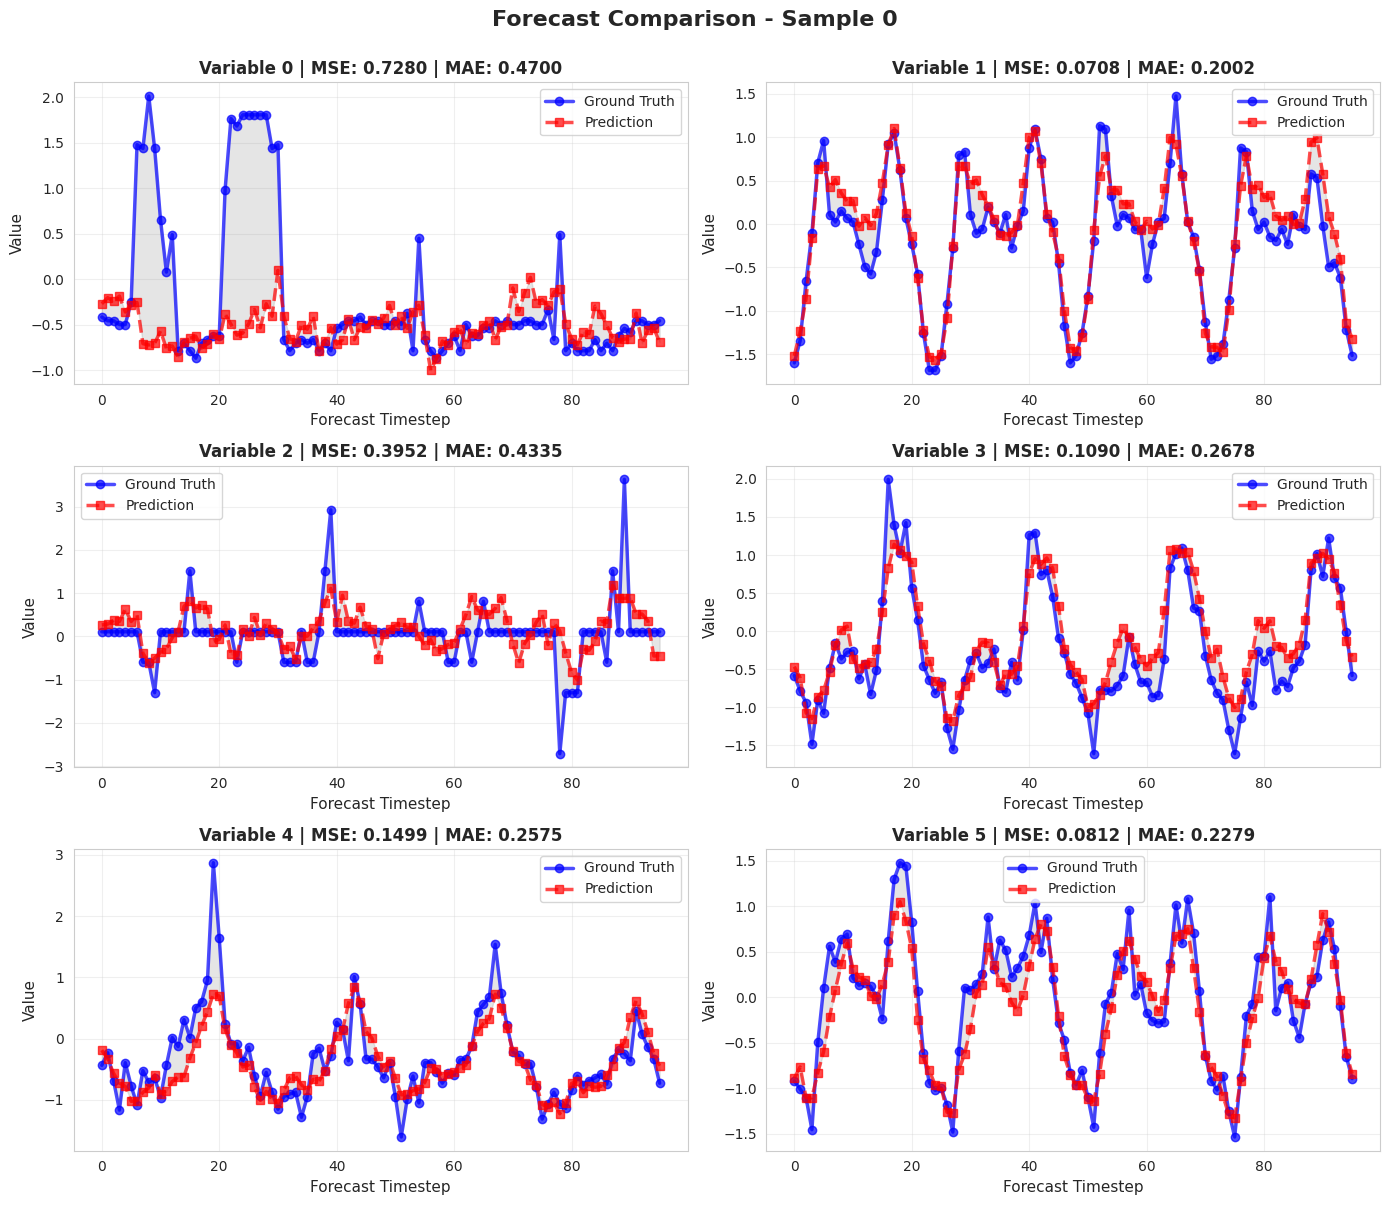


STEP 6: Saving Results


In [29]:
# Plot training history
output_dir = ''
print("\nGenerating training history plot...")
plot_training_history(
    history=history
)

# Plot sample predictions
print("\nGenerating sample predictions plot...")
plot_predictions(
    predictions=predictions,
    targets=targets,
    num_samples=3,
    num_variables=5
)

# Plot error distribution
print("\nGenerating error distribution plot...")
plot_error_distribution(
    predictions=predictions,
    targets=targets
)

# Plot variable performance
print("\nGenerating variable performance plot...")
plot_variable_performance(
    predictions=predictions,
    targets=targets
)

# Plot detailed forecast comparison
print("\nGenerating detailed forecast comparison...")
plot_forecast_comparison(
    predictions=predictions,
    targets=targets,
    sample_idx=0
)

print("\n" + "="*60)
print("STEP 6: Saving Results")
print("="*60)


In [28]:
import os

# Save model
model_path = os.path.join(output_dir, 'final_model.pt')
torch.save(model.state_dict(), model_path)
print(f"\nModel saved to: {model_path}")

# Save configuration
import json
config_path = os.path.join(output_dir, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config.to_dict(), f, indent=2)
print(f"Configuration saved to: {config_path}")

# Save results summary
results = {
    'train_loss': float(history['train_loss'][-1]),
    'valid_loss': float(history['valid_loss'][-1]),
    'test_loss': float(test_loss),
    'test_rmse': float(np.sqrt(test_loss)),
    'num_variables': int(data.shape[1]),
    'total_timesteps': int(data.shape[0])
}
print(results)

results_path = os.path.join(output_dir, 'results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved to: {results_path}")

print("\n" + "="*60)
print("PIPELINE COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"\nAll outputs saved to: {output_dir}")
print(f"\nFinal Results:")
print(f"  Train Loss: {results['train_loss']:.4f}")
print(f"  Valid Loss: {results['valid_loss']:.4f}")
print(f"  Test Loss: {results['test_loss']:.4f}")



Model saved to: final_model.pt
Configuration saved to: config.json
{'train_loss': 0.16182852940403153, 'valid_loss': 0.17957589752040803, 'test_loss': 0.1730639768177516, 'test_rmse': 0.41600958741085714, 'num_variables': 321, 'total_timesteps': 26304}
Results saved to: results.json

PIPELINE COMPLETED SUCCESSFULLY!

All outputs saved to: 

Final Results:
  Train Loss: 0.1618
  Valid Loss: 0.1796
  Test Loss: 0.1731
